In [12]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/telco-churn.csv')

# Preview the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Inspect column names and data types
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender  

In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Confirm conversion
print(df['TotalCharges'].dtype)
print("Missing values after conversion:", df['TotalCharges'].isnull().sum())

float64
Missing values after conversion: 11


In [15]:
# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Confirm cleaned dataset shape:
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (7032, 21)


In [16]:
# Business Question 1: What is the overall churn rate?
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)
print("\nChurn rate:")
print(churn_rate.round(1))

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


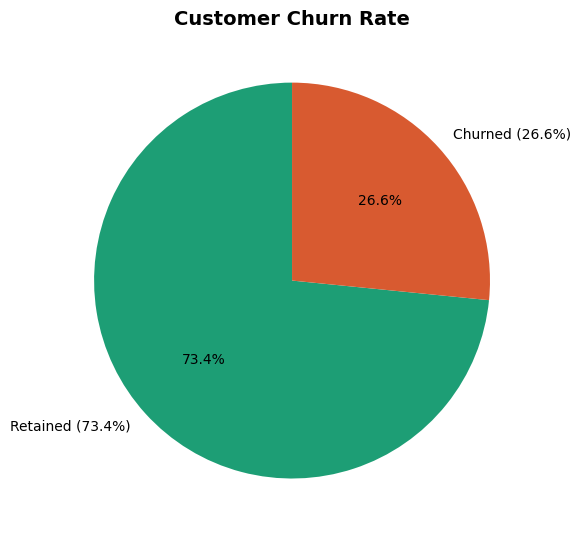

In [ ]:
import matplotlib.pyplot as plt

# Overall churn rate — pie chart
fig, ax = plt.subplots(figsize=(6, 6))

colors = ['#1D9E75', '#D85A30']
ax.pie(churn_counts, 
       labels=['Retained (73.4%)', 'Churned (26.6%)'],
       colors=colors,
       autopct='%1.1f%%',
       startangle=90)

ax.set_title('Customer Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Business Question 2: How does contract type affect churn?
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

print(contract_churn.round(1))

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


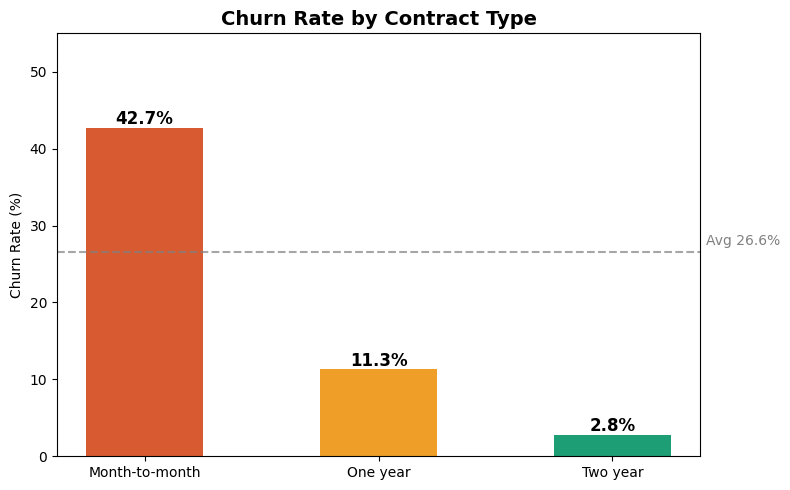

In [ ]:
# Churn rate by contract type
fig, ax = plt.subplots(figsize=(8, 5))

contract_types = ['Month-to-month', 'One year', 'Two year']
churn_rates = [42.7, 11.3, 2.8]
colors = ['#D85A30', '#EF9F27', '#1D9E75']

bars = ax.bar(contract_types, churn_rates, color=colors, width=0.5)

# Add percentage labels above each bar
for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.5,
            f'{rate}%', 
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.axhline(y=26.6, color='gray', linestyle='--', alpha=0.7)
ax.text(2.4, 27.5, 'Avg 26.6%', color='gray', fontsize=10)

plt.tight_layout()
plt.savefig('charts/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

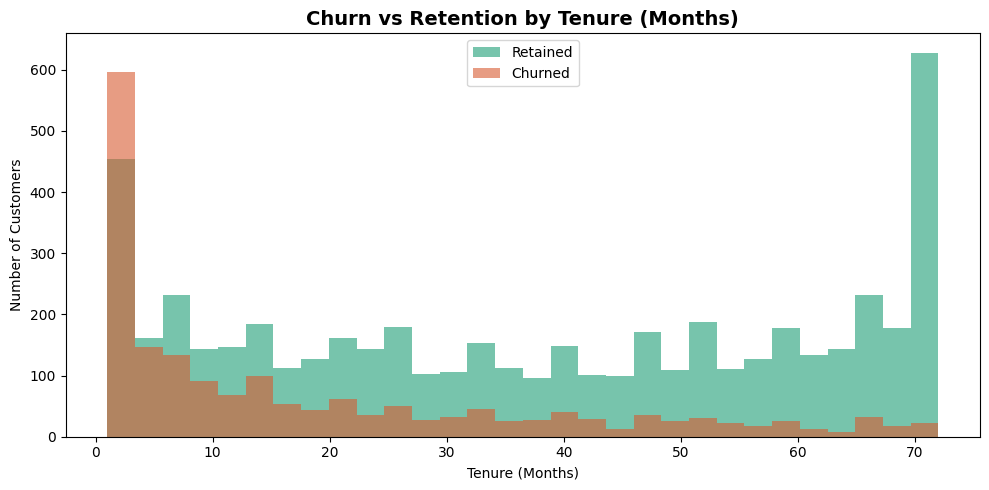

In [ ]:
# Business Question 3: Does tenure affect churn?
fig, ax = plt.subplots(figsize=(10, 5))

# Split churned and retained users by tenure
churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

ax.hist(retained, bins=30, alpha=0.6, color='#1D9E75', label='Retained')
ax.hist(churned, bins=30, alpha=0.6, color='#D85A30', label='Churned')

ax.set_title('Churn vs Retention by Tenure (Months)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('charts/churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

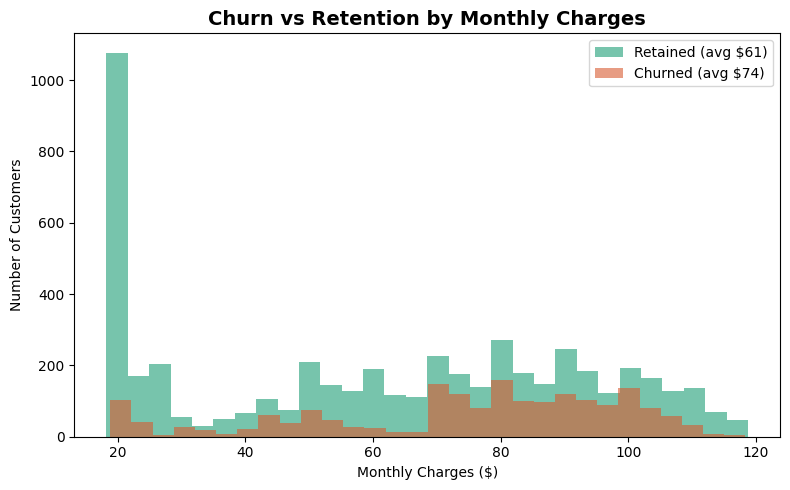

In [ ]:
# Business Question 4: Do monthly charges affect churn?
fig, ax = plt.subplots(figsize=(8, 5))

churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df[df['Churn'] == 'No']['MonthlyCharges']

ax.hist(retained_charges, bins=30, alpha=0.6, 
        color='#1D9E75', label=f'Retained (avg ${retained_charges.mean():.0f})')
ax.hist(churned_charges, bins=30, alpha=0.6, 
        color='#D85A30', label=f'Churned (avg ${churned_charges.mean():.0f})')

ax.set_title('Churn vs Retention by Monthly Charges', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('charts/churn_by_charges.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings & Business Recommendations

### Finding 1: High Overall Churn Rate
- 26.6% of customers have churned — significantly above the healthy benchmark of 5–10%
- **Recommendation:** Launch a company-wide retention initiative immediately

### Finding 2: Contract Type is the Strongest Predictor
- Month-to-month users churn at 42.7% vs only 2.8% for two-year contracts
- **Recommendation:** Offer discounts or perks to incentivize annual/two-year commitments

### Finding 3: The First 10 Months are Critical
- Churn is heavily concentrated in the first 10 months of tenure
- **Recommendation:** Build a structured onboarding program for new users in months 1–10

### Finding 4: High-Paying Users Are at Risk
- Churned customers pay 21% more on average ($74 vs $61/month)
- **Recommendation:** Create a premium retention program with added value for high-spend users